# DPC/BF segmentation trials on IPSDM

In [1]:
import zarr
import os
import dask.array as da
from pathlib import Path 
import micro_sam
import napari
import numpy as np
from skimage import io

In [2]:
acq_ID = (3, 3)
row, column = acq_ID

In [3]:
def timed_compute(volume):
    """
    Compute a lazy Dask array frame-by-frame with progress reporting.

    This function iterates over the leading axis of a Dask array (e.g. time),
    calls `.compute()` on each slice, and stacks the results into a single
    NumPy array. A tqdm progress bar is displayed to indicate progress.

    Parameters
    ----------
    volume : dask.array.Array
        A Dask array with at least one dimension (e.g. shape (T, ...)).
        The function will iterate over the first axis (axis=0).

    Returns
    -------
    numpy.ndarray
        A NumPy array with the same shape as `volume`, but fully realized
        in memory. The dtype is preserved from the Dask array.

    Notes
    -----
    - Each frame is computed independently, which can be helpful for
      monitoring performance and memory use on large arrays.
    - The returned array may be very large if `volume` is large.
      Ensure sufficient memory is available.
    """
    import numpy as np
    from tqdm.auto import tqdm
    return np.stack([frame.compute() for frame in tqdm(volume)], axis=0)

In [6]:
base_dir = '/mnt/OPERA3/Nathan/data/heterognosis/BPP0042/BPP0042_24hpi/'
store = Path(base_dir, f'acquisition/zarr/{acq_ID}.zarr')

In [7]:
images = da.from_zarr(Path(store, "images"))

In [8]:
%%time
img_bf_z0 = images[-1, -1, 0].compute()

CPU times: user 3.41 s, sys: 8.75 s, total: 12.2 s
Wall time: 22.1 s


In [9]:
img_bf_z0

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0, 476, 458, ..., 412, 446,   0],
       [  0, 477, 475, ..., 435, 459,   0],
       ...,
       [  0, 431, 405, ..., 374, 370,   0],
       [  0, 410, 397, ..., 426, 440,   0],
       [  0,   0,   0, ...,   0,   0,   0]],
      shape=(6911, 6911), dtype=uint16)

In [10]:
images = timed_compute(images[-1].max(axis=1)

SyntaxError: incomplete input (1739408668.py, line 1)

# Doing some manual segmentation

In [11]:
viewer = napari.Viewer(title='IPS DPC BF manual segmentation, round 2 24hpi, microsam tests')

In [12]:
viewer.add_image(img_bf_z0)

<Image layer 'img_bf_z0' at 0x75c348dbedd0>

/home/dayn/miniconda3/envs/micro-sam/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO: Computed embeddings for the 'Light Microscopy' model of size 'base'.


In [19]:
viewer.add_image(images, channel_axis=0)

[<Image layer 'Image' at 0x3a0a629b0>,
 <Image layer 'Image [1]' at 0x3a0a62530>,
 <Image layer 'Image [2]' at 0x3a09b2a40>]

In [ ]:
viewer.add_image(img)

In [ ]:
print()

In [13]:
img_fn = os.path.join(base_dir, f'labels/dev/{acq_ID}_t0_DPC.tif')
os.makedirs(os.path.dirname(img_fn), exist_ok=True)
io.imsave(img_fn, images[0])

In [17]:
img_fn = os.path.join(base_dir, f'labels/dev/{acq_ID}_t0_BF.tif')
io.imsave(img_fn, images[-1])

/mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/(3, 3)_t0_BF.tif


In [7]:
img_fn = os.path.join(base_dir, f'labels/dev/{acq_ID}_t0_BF.tif')
# io.imsave(img_fn, images[-1])

'/Volumes/OPERA3/Nathan/data/heterognosis/BPP0042/BPP0042_24hpi/labels/dev/(3, 3)_t0_BF.tif'

# Load masks

In [43]:
import glob
from tqdm.auto import tqdm

In [48]:
masks_fns = glob.glob('/Volumes/OPERA3/Nathan/data/heterognosis/BPP0042/BPP0042_24hpi/labels/dev/*.npy')
for fn in tqdm(masks_fns):
    masks_ = np.load(fn)
    viewer.add_labels(masks_, name = os.path.basename(fn))

  0%|          | 0/6 [00:00<?, ?it/s]

In [50]:
files = glob.glob(os.path.join(base_dir, "labels/dev/cpsam_t0_(3, 3)_BF_DPC*.npy"))
latest = max(files, key=os.path.getmtime)

masks = np.load(latest)
print("Loaded:", latest)

Loaded: /Volumes/OPERA3/Nathan/data/heterognosis/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250519_111356.npy


In [54]:
import os, glob, re
from datetime import datetime

base_dir = "/Volumes/OPERA3/Nathan/data/heterognosis/BPP0042/BPP0042_24hpi"
files = glob.glob(os.path.join(base_dir, "labels/dev/cpsam_t0_(3, 3)_BF_DPC*.npy"))

pattern = re.compile(r".*_(\d{8}_\d{6})\.npy$")

# collect (file, timestamp) pairs
file_times = []
for f in files:
    m = pattern.search(os.path.basename(f))
    if m:
        ts = datetime.strptime(m.group(1), "%Y%m%d_%H%M%S")
        file_times.append((f, ts))

# sort by timestamp
file_times.sort(key=lambda x: x[1])

# print file and delta to previous
prev = None
for f, ts in file_times:
    if prev is None:
        print(f"{os.path.basename(f):45}  {ts}   Δ: ---")
    else:
        delta = ts - prev
        print(f"{os.path.basename(f):45}  {ts}   Δ: {delta}")
    prev = ts

cpsam_t0_(3, 3)_BF_DPC_20250515_155248.npy     2025-05-15 15:52:48   Δ: ---
cpsam_t0_(3, 3)_BF_DPC_20250515_160601.npy     2025-05-15 16:06:01   Δ: 0:13:13
cpsam_t0_(3, 3)_BF_DPC_20250515_163830.npy     2025-05-15 16:38:30   Δ: 0:32:29
cpsam_t0_(3, 3)_BF_DPC_20250519_111340.npy     2025-05-19 11:13:40   Δ: 3 days, 18:35:10
cpsam_t0_(3, 3)_BF_DPC_20250519_111356.npy     2025-05-19 11:13:56   Δ: 0:00:16


In [51]:
viewer.add_labels(masks)

<Labels layer 'masks' at 0x15ac9a440>

In [52]:
base_dir

'/Volumes/OPERA3/Nathan/data/heterognosis/BPP0042/BPP0042_24hpi/'

In [41]:
@viewer.bind_key('s', overwrite=True)  # Press 's' to save the labels layer
def save_labels(viewer):
    base_dir = '/Volumes/OPERA3/Nathan/data/heterognosis/BPP0042/BPP0042_24hpi/labels/dev/'
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f'cpsam_t0_{acq_ID}_BF_DPC_{timestamp}.npy'
    save_path = os.path.join(base_dir, filename)

    # Save new file
    np.save(save_path, viewer.layers['masks'].data)
    print(f"Labels layer saved to: {save_path}")

    # Manage rotating saves
    pattern = os.path.join(base_dir, f'cpsam_t*_{acq_ID}_BF_DPC_*.npy')
    matching_files = sorted(glob.glob(pattern), key=os.path.getmtime)

    if len(matching_files) > 5:
        for old_file in matching_files[:-5]:
            os.remove(old_file)
            print(f"Deleted old save: {old_file}")

Labels layer saved to: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250512_171901.npy
Deleted old save: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250508_153717.npy
Deleted old save: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250508_153728.npy
Deleted old save: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250512_171749.npy
Deleted old save: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250512_171800.npy
Deleted old save: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250512_171808.npy
Deleted old save: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250512_171837.npy
Deleted old save: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250512_171840.npy
Labels layer saved to: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250512_171921.npy
Deleted old save: /mnt/DATA3/BPP0042/BPP0042_

In [71]:
print()


Labels layer saved to: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250519_111356.npy
Deleted old save: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250515_155247.npy


In [68]:
@viewer.bind_key('a', overwrite=True)  # Press 's' to save the labels layer
def switch_background(viewer):
    viewer.layers['Image [2]'].visible = not viewer.layers['Image [2]'].visible
    viewer.layers['Image'].visible = not viewer.layers['Image'].visible 

Labels layer saved to: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250513_141651.npy
Deleted old save: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250513_123713.npy
Labels layer saved to: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250513_143319.npy
Deleted old save: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250513_123714.npy
Labels layer saved to: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250513_143517.npy
Deleted old save: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250513_123718.npy
Labels layer saved to: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250513_143657.npy
Deleted old save: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250513_123719.npy
Labels layer saved to: /mnt/DATA3/BPP0042/BPP0042_24hpi/labels/dev/cpsam_t0_(3, 3)_BF_DPC_20250513_164628.npy
Deleted old save: /mnt/DATA3/B

In [11]:
import os
import re
from tqdm.auto import tqdm
from collections import Counter

# Initialize counters and lists
missing_file_count = 0
missing_files = []
missing_by_channel = Counter()

# Regular expression to extract channel information
# This pattern looks for "ch" followed by digits
channel_pattern = re.compile(r'ch(\d+)')

for fn in tqdm(metadata['URL'].values):
    if not os.path.exists(os.path.join(path, 'Images', fn)):
        missing_file_count += 1
        missing_files.append(fn)
        
        # Extract channel number from filename
        channel_match = channel_pattern.search(fn)
        if channel_match:
            channel_number = channel_match.group(1)  # Extract the digit(s) after 'ch'
            missing_by_channel[channel_number] += 1
        else:
            missing_by_channel['unknown'] += 1

# Print summary
print(f"Total missing files: {missing_file_count}")
print("\nMissing files by channel:")
for channel, count in missing_by_channel.most_common():
    print(f"Channel {channel}: {count} files")

# Optional: Calculate percentage by channel
if missing_file_count > 0:
    print("\nPercentage by channel:")
    for channel, count in missing_by_channel.most_common():
        percentage = (count / missing_file_count) * 100
        print(f"Channel {channel}: {percentage:.2f}%")

  0%|          | 0/126954 [00:00<?, ?it/s]

Total missing files: 28212

Missing files by channel:
Channel 1: 28212 files

Percentage by channel:
Channel 1: 100.00%


## Running segmentation test regardless

In [54]:
from skimage import io
import matplotlib.pyplot as plt
import napari

### Testing tile compilation

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 126954/126954 [00:51<00:00, 2448.99it/s]


Total missing files: 28212

Missing files by channel:
Channel 1: 28212 files

Row/Col combinations with missing files:
Row 3, Col 2: 4704/21168 files missing (22.22%)
Row 3, Col 3: 4704/21168 files missing (22.22%)
Row 3, Col 4: 4704/21168 files missing (22.22%)
Row 4, Col 3: 4704/21168 files missing (22.22%)
Row 4, Col 4: 4702/21159 files missing (22.22%)
Row 3, Col 1: 4694/21123 files missing (22.22%)


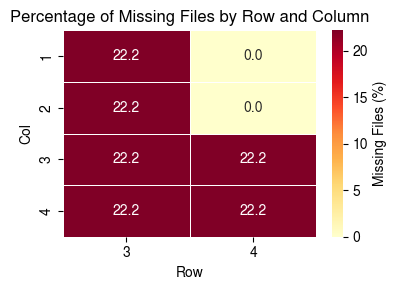

In [19]:
import os
import re
from tqdm import tqdm
from collections import Counter, defaultdict
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set Nimbus Sans as the default font family
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Nimbus Sans', 'Nimbus Sans L', 'NimbusSans', 'NimbusSansL']

# Initialize counters and data structures
missing_file_count = 0
missing_files = []
missing_by_channel = Counter()
missing_by_row_col = defaultdict(list)
missing_count_by_row_col = Counter()

# Extract filename from URL if needed
# Some metadata systems store the full URL rather than just the filename
def extract_filename(url_or_path):
    if '/' in url_or_path:
        return os.path.basename(url_or_path)
    return url_or_path

# Regular expression to extract channel information
channel_pattern = re.compile(r'ch(\d+)')

# Check missing files and collect statistics
for idx, row in tqdm(metadata.iterrows(), total=len(metadata)):
    fn = row['URL']
    if not os.path.exists(os.path.join(path, 'Images', fn)):
        missing_file_count += 1
        missing_files.append(fn)
        
        # Extract channel number from filename
        channel_match = channel_pattern.search(fn)
        channel_number = channel_match.group(1) if channel_match else 'unknown'
        missing_by_channel[channel_number] += 1
        
        # Get row and column for this file
        row_num = row['Row'] if 'Row' in metadata.columns else None
        col_num = row['Col'] if 'Col' in metadata.columns else None
        
        if row_num is not None and col_num is not None:
            row_col_key = (row_num, col_num)
            missing_by_row_col[row_col_key].append({
                'filename': fn,
                'channel': channel_number
            })
            missing_count_by_row_col[row_col_key] += 1

# Create a summary dataframe of all row/col combinations
all_row_col_combinations = []
rows = metadata['Row'].unique() if 'Row' in metadata.columns else []
cols = metadata['Col'].unique() if 'Col' in metadata.columns else []

for row_num in rows:
    for col_num in cols:
        key = (row_num, col_num)
        missing_count = missing_count_by_row_col[key]
        total_files = len(metadata[(metadata['Row'] == row_num) & (metadata['Col'] == col_num)])
        present_count = total_files - missing_count
        
        all_row_col_combinations.append({
            'Row': row_num,
            'Col': col_num,
            'Missing': missing_count,
            'Present': present_count,
            'Total': total_files,
            'Missing_Percentage': (missing_count / total_files * 100) if total_files > 0 else 0
        })

# Convert to DataFrame for easier analysis
row_col_df = pd.DataFrame(all_row_col_combinations)

# Print summary
print(f"Total missing files: {missing_file_count}")
print("\nMissing files by channel:")
for channel, count in missing_by_channel.most_common():
    print(f"Channel {channel}: {count} files")

print("\nRow/Col combinations with missing files:")
for (row_num, col_num), count in missing_count_by_row_col.most_common():
    total = len(metadata[(metadata['Row'] == row_num) & (metadata['Col'] == col_num)])
    percentage = (count / total * 100) if total > 0 else 0
    print(f"Row {row_num}, Col {col_num}: {count}/{total} files missing ({percentage:.2f}%)")

# Create a heatmap visualization
plt.figure(figsize=(4, 3))
heatmap_data = row_col_df.pivot(index='Col', columns='Row', values='Missing_Percentage')
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='YlOrRd', 
            linewidths=.5, cbar_kws={'label': 'Missing Files (%)'})
plt.title('Percentage of Missing Files by Row and Column')
plt.tight_layout()
plt.savefig('missing_files_heatmap.png')
plt.show()

# Save detailed results
row_col_df.to_csv('row_col_missing_summary.csv', index=False)

# Save list of missing files with their row/col information
missing_files_detailed = []
for (row_num, col_num), files in missing_by_row_col.items():
    for file_info in files:
        missing_files_detailed.append({
            'Row': row_num,
            'Col': col_num,
            'Filename': file_info['filename'],
            'Channel': file_info['channel']
        })

In [77]:
metadata[['Row', 'Col']].drop_duplicates()

,Row,Col
0,3,1
441,3,2
882,3,3
1323,3,4
1764,4,3
2205,4,4


In [110]:
metadata.keys()

Index(['id', 'State', 'URL', 'Row', 'Col', 'FieldID', 'PlaneID', 'TimepointID',
       'ChannelID', 'FlimID', 'ChannelName', 'ImageType', 'AcquisitionType',
       'IlluminationType', 'ChannelType', 'ImageResolutionX',
       'ImageResolutionY', 'ImageSizeX', 'ImageSizeY', 'BinningX', 'BinningY',
       'MaxIntensity', 'CameraType', 'PositionX', 'PositionY', 'PositionZ',
       'AbsPositionZ', 'MeasurementTimeOffset', 'AbsTime',
       'MainExcitationWavelength', 'MainEmissionWavelength',
       'ObjectiveMagnification', 'ObjectiveNA', 'ExposureTime',
       'OrientationMatrix'],
      dtype='object')

In [80]:
# Count how many entries exist for each Row and Col combination
row_col_counts = metadata.groupby(['Row', 'Col']).size().reset_index(name='Count')

# Display the result
row_col_counts

,Row,Col,Count
0,3,1,2205
1,3,2,2205
2,3,3,2205
3,3,4,2205
4,4,3,2205
5,4,4,2187


In [76]:
metadata[(metadata['Row'] == '4')]

,id,State,URL,Row,Col,FieldID,PlaneID,TimepointID,ChannelID,FlimID,...,PositionZ,AbsPositionZ,MeasurementTimeOffset,AbsTime,MainExcitationWavelength,MainEmissionWavelength,ObjectiveMagnification,ObjectiveNA,ExposureTime,OrientationMatrix
1764,0403K1F1P1R1,Ok,r04c03f01p01-ch1sk1fk1fl1.tiff,4,3,1,1,0,1,1,...,4.697E-06,0.135173693,0,2025-02-22T15:46:50.723+00:00,740,0,63,1.15,0.1,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."
1765,0403K1F1P1R2,Ok,r04c03f01p01-ch2sk1fk1fl1.tiff,4,3,1,1,0,2,1,...,1E-06,0.135177001,0,2025-02-22T15:46:51.207+00:00,488,522,63,1.15,0.16,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."
1766,0403K1F1P1R3,Ok,r04c03f01p01-ch3sk1fk1fl1.tiff,4,3,1,1,0,3,1,...,1E-06,0.135177001,0,2025-02-22T15:46:51.427+00:00,740,0,63,1.15,0.1,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."
1767,0403K1F1P2R1,Ok,r04c03f01p02-ch1sk1fk1fl1.tiff,4,3,1,2,0,1,1,...,4.697E-06,0.135173693,0,2025-02-22T15:46:50.723+00:00,740,0,63,1.15,0.1,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."
1768,0403K1F1P2R2,Ok,r04c03f01p02-ch2sk1fk1fl1.tiff,4,3,1,2,0,2,1,...,3E-06,0.135178998,0,2025-02-22T15:46:51.737+00:00,488,522,63,1.15,0.16,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13207,0404K5F49P2R2,Ok,r04c04f49p02-ch2sk5fk1fl1.tiff,4,4,49,2,4,2,1,...,3E-06,0.135152802,7207.527,2025-02-22T17:54:59.103+00:00,488,522,63,1.15,0.16,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."
13208,0404K5F49P2R3,Ok,r04c04f49p02-ch3sk5fk1fl1.tiff,4,4,49,2,4,3,1,...,3E-06,0.135152802,7207.527,2025-02-22T17:54:59.337+00:00,740,0,63,1.15,0.1,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."
13209,0404K5F49P3R1,Ok,r04c04f49p03-ch1sk5fk1fl1.tiff,4,4,49,3,4,1,1,...,4.697E-06,0.135147497,7207.527,2025-02-22T17:54:58.107+00:00,740,0,63,1.15,0.1,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."
13210,0404K5F49P3R2,Ok,r04c04f49p03-ch2sk5fk1fl1.tiff,4,4,49,3,4,2,1,...,5E-06,0.135154799,7207.527,2025-02-22T17:54:59.633+00:00,488,522,63,1.15,0.16,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."


In [84]:
image_dir = os.path.join(path, 'Images')
row = 4
column = 2

In [85]:
dask_images = tile.compile_mosaic(image_dir, metadata, row, column)

IndexError: single positional indexer is out-of-bounds

In [88]:
metadata[(metadata['Row'] == str(row)) & (metadata['Col'] == str(column))]

,id,State,URL,Row,Col,FieldID,PlaneID,TimepointID,ChannelID,FlimID,...,PositionZ,AbsPositionZ,MeasurementTimeOffset,AbsTime,MainExcitationWavelength,MainEmissionWavelength,ObjectiveMagnification,ObjectiveNA,ExposureTime,OrientationMatrix


In [69]:
metadata['URL'][(metadata['Row'] == str(row))
                & (metadata['Col'] == str(col))]

Series([], Name: URL, dtype: object)

In [126]:

# Define the position to tile
row_to_tile = '3'
col_to_tile = '3'

# Filter metadata for the specified row and column
position_metadata = metadata[(metadata['Row'] == row_to_tile) & (metadata['Col'] == col_to_tile)]
position_metadata

,id,State,URL,Row,Col,FieldID,PlaneID,TimepointID,ChannelID,FlimID,...,PositionZ,AbsPositionZ,MeasurementTimeOffset,AbsTime,MainExcitationWavelength,MainEmissionWavelength,ObjectiveMagnification,ObjectiveNA,ExposureTime,OrientationMatrix
882,0303K1F1P1R1,Ok,r03c03f01p01-ch1sk1fk1fl1.tiff,3,3,1,1,0,1,1,...,4.697E-06,0.135175198,0,2025-02-22T15:48:49.317+00:00,740,0,63,1.15,0.1,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."
883,0303K1F1P1R2,Ok,r03c03f01p01-ch2sk1fk1fl1.tiff,3,3,1,1,0,2,1,...,1E-06,0.135178402,0,2025-02-22T15:48:49.797+00:00,488,522,63,1.15,0.16,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."
884,0303K1F1P1R3,Ok,r03c03f01p01-ch3sk1fk1fl1.tiff,3,3,1,1,0,3,1,...,1E-06,0.135178402,0,2025-02-22T15:48:50.033+00:00,740,0,63,1.15,0.1,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."
885,0303K1F1P2R1,Ok,r03c03f01p02-ch1sk1fk1fl1.tiff,3,3,1,2,0,1,1,...,4.697E-06,0.135175198,0,2025-02-22T15:48:49.317+00:00,740,0,63,1.15,0.1,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."
886,0303K1F1P2R2,Ok,r03c03f01p02-ch2sk1fk1fl1.tiff,3,3,1,2,0,2,1,...,3E-06,0.135180399,0,2025-02-22T15:48:50.33+00:00,488,522,63,1.15,0.16,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11893,0303K5F49P2R2,Ok,r03c03f49p02-ch2sk5fk1fl1.tiff,3,3,49,2,4,2,1,...,3E-06,0.135180205,7203.7329999999993,2025-02-22T17:50:53.077+00:00,488,522,63,1.15,0.16,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."
11894,0303K5F49P2R3,Ok,r03c03f49p02-ch3sk5fk1fl1.tiff,3,3,49,2,4,3,1,...,3E-06,0.135180205,7203.7329999999993,2025-02-22T17:50:53.293+00:00,740,0,63,1.15,0.1,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."
11895,0303K5F49P3R1,Ok,r03c03f49p03-ch1sk5fk1fl1.tiff,3,3,49,3,4,1,1,...,4.697E-06,0.1351749,7203.7329999999993,2025-02-22T17:50:52.06+00:00,740,0,63,1.15,0.1,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."
11896,0303K5F49P3R2,Ok,r03c03f49p03-ch2sk5fk1fl1.tiff,3,3,49,3,4,2,1,...,5E-06,0.135182202,7203.7329999999993,2025-02-22T17:50:53.59+00:00,488,522,63,1.15,0.16,"[[0.992244,0,0,27.9],[0,-0.992244,0,-6.3],[0,0..."


In [172]:
metadata['TimepointID'].max()

'4'

In [120]:
import numpy as np
import dask.array as da
from dask import delayed
from skimage import io
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

Fields: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '6', '7', '8', '9']
Planes: ['1', '2', '3']
Channels: ['1', '2', '3']
Using image dimensions: 1080 x 1080
Creating dask array for plane 1, channel 1
Dask array shape: (49, 1080, 1080) (fields, height, width)
Computing the first field...
First field shape: (1080, 1080)


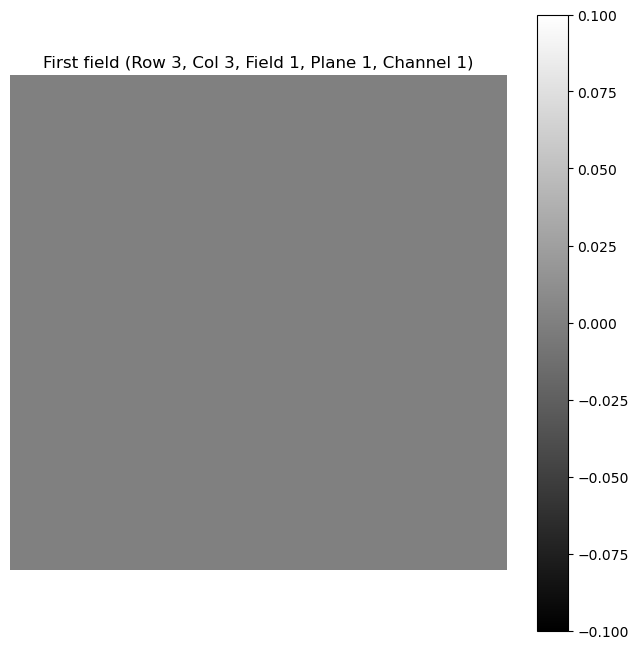

Plotting all fields...


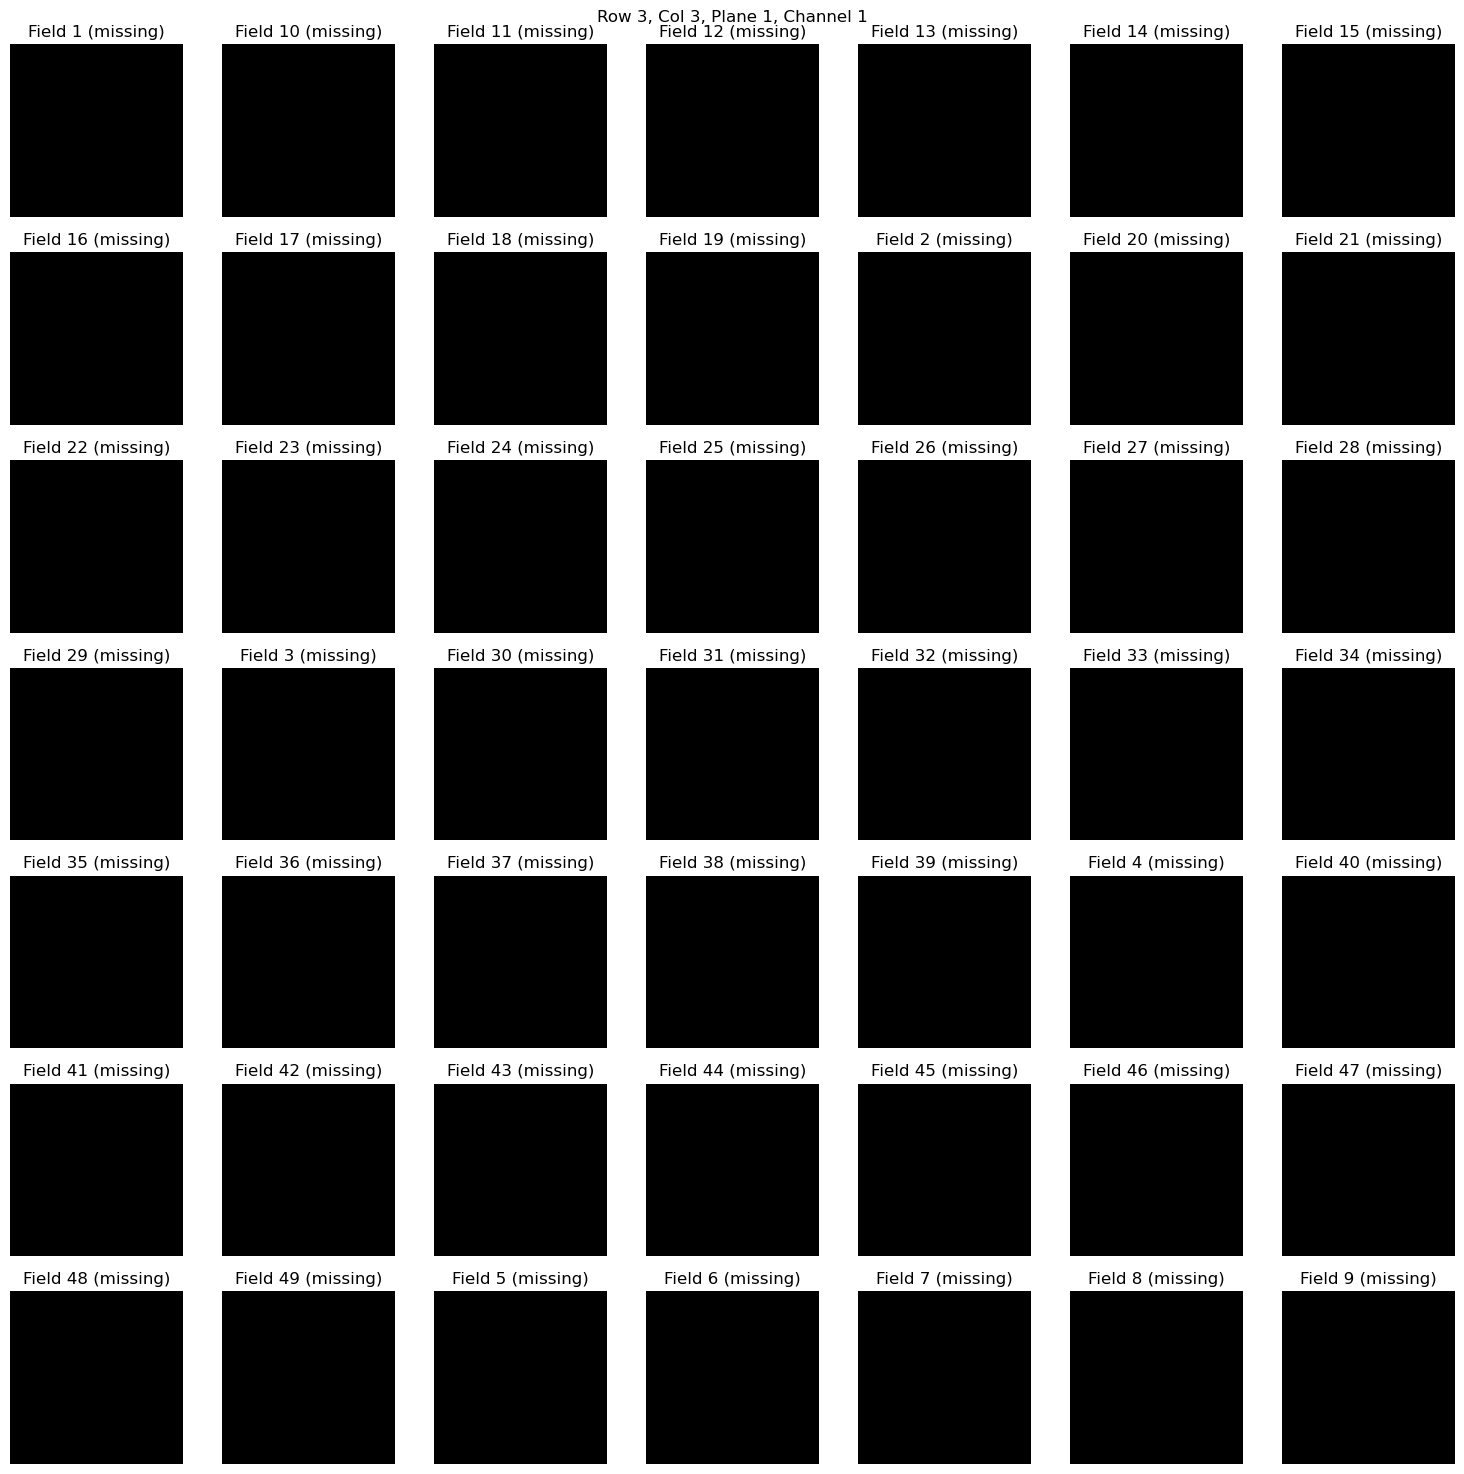

In [127]:
import numpy as np
import dask.array as da
from dask import delayed
from skimage import io
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

# Define the position to tile
row_to_tile = '3'
col_to_tile = '3'

# Filter metadata for the specified row and column
position_metadata = metadata[(metadata['Row'] == row_to_tile) & (metadata['Col'] == col_to_tile)]

# Get unique values for fields, planes, and channels
fields = sorted(position_metadata['FieldID'].unique())
planes = sorted(position_metadata['PlaneID'].unique())
channels = sorted(position_metadata['ChannelID'].unique())

print(f"Fields: {fields}")
print(f"Planes: {planes}")
print(f"Channels: {channels}")

# Get image size from metadata if available, otherwise use a default
# Make sure we convert to integer values
if len(position_metadata) > 0 and 'ImageSizeX' in position_metadata.columns and 'ImageSizeY' in position_metadata.columns:
    # Convert to int to avoid string type issues
    img_width = int(position_metadata['ImageSizeX'].iloc[0])
    img_height = int(position_metadata['ImageSizeY'].iloc[0])
else:
    # Default size if not found in metadata
    img_width = 2048
    img_height = 2048

print(f"Using image dimensions: {img_width} x {img_height}")

# Define a delayed function to load an image or return a blank one
@delayed
def delayed_load_image(file_path, height=img_height, width=img_width):
    if os.path.exists(file_path):
        try:
            return io.imread(file_path)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            return np.zeros((height, width), dtype=np.uint16)
    else:
        print(f"File not found: {file_path}")
        return np.zeros((height, width), dtype=np.uint16)

# Create dask arrays for a single plane and channel
def create_single_plane_channel_dask_array(selected_plane, selected_channel):
    """
    Creates a dask array for the specified plane and channel.
    
    Returns:
        dask array with shape (fields, height, width)
    """
    # Create delayed objects for all images
    delayed_images = []
    
    for field_id in fields:
        # Get metadata for this specific field, plane, and channel
        img_meta = position_metadata[
            (position_metadata['FieldID'] == field_id) & 
            (position_metadata['PlaneID'] == selected_plane) & 
            (position_metadata['ChannelID'] == selected_channel)
        ]
        
        # Get the file path if it exists in metadata
        if len(img_meta) > 0:
            file_path = os.path.join(path, 'Images', img_meta['URL'].iloc[0])
        else:
            file_path = ""
        
        # Add delayed image loading
        delayed_images.append(delayed_load_image(file_path))
    
    # Create the dask array
    lazy_arrays = [da.from_delayed(delayed_img, shape=(img_height, img_width), dtype=np.uint16) 
                   for delayed_img in delayed_images]
    
    # Stack them into a single dask array
    return da.stack(lazy_arrays, axis=0)

# Create a simplified version that avoids complex nested loops
if fields and planes and channels:
    # Select specific plane and channel for demonstration
    selected_plane = planes[0]
    selected_channel = channels[0]
    
    print(f"Creating dask array for plane {selected_plane}, channel {selected_channel}")
    
    try:
        # Create the dask array for a single plane and channel
        dask_tiled_array = create_single_plane_channel_dask_array(selected_plane, selected_channel)
        print(f"Dask array shape: {dask_tiled_array.shape} (fields, height, width)")
        
        # Determine grid size for tiling
        grid_size = int(np.ceil(np.sqrt(len(fields))))
        
        # Visualize the first field to check everything is working
        print("Computing the first field...")
        first_field = dask_tiled_array[0].compute()
        print(f"First field shape: {first_field.shape}")
        
        # Plot the first field
        plt.figure(figsize=(8, 8))
        plt.imshow(first_field, cmap='gray')
        plt.title(f"First field (Row {row_to_tile}, Col {col_to_tile}, Field {fields[0]}, Plane {selected_plane}, Channel {selected_channel})")
        plt.colorbar()
        plt.axis('off')
        plt.show()
        
        # Plot all fields (computing only when needed)
        print("Plotting all fields...")
        plt.figure(figsize=(15, 15))
        
        for i, field_idx in enumerate(range(len(fields))):
            field_id = fields[field_idx]
            
            # Get metadata for this field
            img_meta = position_metadata[
                (position_metadata['FieldID'] == field_id) & 
                (position_metadata['PlaneID'] == selected_plane) & 
                (position_metadata['ChannelID'] == selected_channel)
            ]
            
            has_file = False
            if len(img_meta) > 0:
                file_path = os.path.join(path, 'Images', img_meta['URL'].iloc[0])
                has_file = os.path.exists(file_path)
            
            # Compute this field's image
            field_img = dask_tiled_array[field_idx].compute()
            
            # Add to plot
            plt.subplot(grid_size, grid_size, i + 1)
            plt.imshow(field_img, cmap='gray')
            
            # Show whether the file exists or is a blank placeholder
            title = f"Field {field_id}"
            if not has_file:
                title += " (missing)"
            
            plt.title(title)
            plt.axis('off')
        
        plt.suptitle(f"Row {row_to_tile}, Col {col_to_tile}, Plane {selected_plane}, Channel {selected_channel}")
        plt.tight_layout()
        plt.savefig(f'r{row_to_tile}c{col_to_tile}_p{selected_plane}_ch{selected_channel}_tiled_dask.png', dpi=300)
        plt.show()
        
    except Exception as e:
        print(f"Error creating dask array: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"No data found for Row {row_to_tile}, Col {col_to_tile}")

## Test load images

In [ ]:
base_fn = 'r03c04f48p03-ch1sk5fk1fl1.tiff'

In [128]:
test_image_dpc_fn = '/mnt/OPERA2/Baptiste/Live-cell-to-4i/BPP0042/2025-02-21-BPP0042-T24hpi__2025-02-22T15_42_36-Measurement 1/Images/r03c04f48p03-ch1sk5fk1fl1.tiff'
test_image_gfp_fn = '/mnt/OPERA2/Baptiste/Live-cell-to-4i/BPP0042/2025-02-21-BPP0042-T24hpi__2025-02-22T15_42_36-Measurement 1/Images/r03c04f48p03-ch2sk5fk1fl1.tiff'
test_image_bf_fn = '/mnt/OPERA2/Baptiste/Live-cell-to-4i/BPP0042/2025-02-21-BPP0042-T24hpi__2025-02-22T15_42_36-Measurement 1/Images/r03c04f48p03-ch3sk5fk1fl1.tiff'

In [129]:
dpc_image = io.imread(test_image_dpc_fn)
gfp_image = io.imread(test_image_gfp_fn)
bf_image = io.imread(test_image_bf_fn)

In [130]:
image = np.stack([dpc_image, gfp_image, bf_image], axis=0)

In [131]:
viewer = napari.Viewer(title='testing dpc segmentation')
# viewer.add_image(image, channel_axis=0, )

In [132]:
# Define channel properties - name, colormap, and contrast limits
channel_properties = [
    {'name': 'DPC', 'colormap': 'magenta', 'contrast_limits': None},  # DPC typically grayscale
    {'name': 'GFP', 'colormap': 'green', 'contrast_limits': None},  # GFP uses green colormap
    {'name': 'BF', 'colormap': 'gray', 'contrast_limits': None}     # Brightfield typically grayscale
]

# Calculate contrast limits if not provided (2nd and 98th percentiles are often good choices)
for i, props in enumerate(channel_properties):
    if props['contrast_limits'] is None:
        # Get the specific channel
        channel_data = image[i]
        # Calculate percentiles for contrast
        p_low, p_high = np.percentile(channel_data, [2, 98])
        props['contrast_limits'] = [p_low, p_high]

# Add the image with specified channel properties
viewer.add_image(
    image,
    channel_axis=0,
    name=[prop['name'] for prop in channel_properties],
    colormap=[prop['colormap'] for prop in channel_properties],
    contrast_limits=[prop['contrast_limits'] for prop in channel_properties],
    visible=True
)


[<Image layer 'DPC' at 0x7f8b61b2fc70>,
 <Image layer 'GFP' at 0x7f8b6011aa40>,
 <Image layer 'BF' at 0x7f8b39e010c0>]

## Cellpose V3

3.0.11


/tmp/ipykernel_6364/3146058284.py:2: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [150]:
model = denoise.CellposeDenoiseModel(gpu=True, model_type="cyto3",
             restore_type="denoise_cyto3",)# chan2_restore=True)
masks, flows, styles, imgs_dn = model.eval(bf_image, channels=[0,0], diameter=100.)

INFO:cellpose.denoise:>> denoise_cyto3 << model set to be used
INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.denoise:>>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)
INFO:cellpose.models:>> cyto3 << model set to be used
INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>>>> loading model /home/dayn/.cellpose/models/cyto3
INFO:cellpose.models:>>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)


In [150]:
model = denoise.CellposeDenoiseModel(gpu=True, model_type="cyto3",
             restore_type="denoise_cyto3",)# chan2_restore=True)
masks, flows, styles, imgs_dn = model.eval(bf_image, channels=[0,0], diameter=100.)

INFO:cellpose.denoise:>> denoise_cyto3 << model set to be used
INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.denoise:>>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)
INFO:cellpose.models:>> cyto3 << model set to be used
INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>>>> loading model /home/dayn/.cellpose/models/cyto3
INFO:cellpose.models:>>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)


In [152]:
model = denoise.CellposeDenoiseModel(gpu=True, model_type="cyto3",
             restore_type="denoise_cyto3",)# chan2_restore=True)
masks, flows, styles, imgs_dn = model.eval(dpc_image, channels=[0,0], diameter=100.)

INFO:cellpose.denoise:>> denoise_cyto3 << model set to be used
INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.denoise:>>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)
INFO:cellpose.models:>> cyto3 << model set to be used
INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>>>> loading model /home/dayn/.cellpose/models/cyto3
INFO:cellpose.models:>>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)


In [153]:
viewer.add_labels(masks)

<Labels layer 'masks [1]' at 0x7f89a660ba60>

## Test against old cellpose personal model

In [156]:
from cellpose import models

In [157]:
model_path = '/home/dayn/analysis/models/cellpose/PS0000/macrohet_seg'
model = models.CellposeModel(gpu=True, 
                             pretrained_model=model_path)

INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>>>> loading model /home/dayn/analysis/models/cellpose/PS0000/macrohet_seg
INFO:cellpose.models:>>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)
INFO:cellpose.models:>>>> model diam_labels =  188.746 (mean diameter of training ROIs)


In [159]:
masks, flows, styles = model.eval(bf_image, # for default models
                                         channels = [0,0], 
                                         diameter = 100, 
                                         )

In [160]:
viewer.add_labels(masks, name='personal model bf image')

<Labels layer 'personal model bf image' at 0x7f8aad6c3fd0>

In [161]:
masks, flows, styles = model.eval(dpc_image, # for default models
                                         channels = [0,0], 
                                         diameter = 100, 
                                         )

In [162]:
viewer.add_labels(masks, name='personal model dpc image')

<Labels layer 'personal model dpc image' at 0x7f89a659a350>

## Test segmenting bacteria

In [163]:
model = models.CellposeModel(gpu=True, 
                             model_type='bact_fluor_cp3')

INFO:cellpose.models:>> bact_fluor_cp3 << model set to be used
INFO:cellpose.models:Downloading: "https://www.cellpose.org/models/bact_fluor_cp3" to /home/dayn/.cellpose/models/bact_fluor_cp3

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25.3M/25.3M [00:03<00:00, 7.33MB/s]
INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>>>> loading model /home/dayn/.cellpose/models/bact_fluor_cp3
INFO:cellpose.models:>>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)


In [166]:
masks, flows, styles = model.eval(gfp_image, # for default models
                                         channels = [0,0], 
                                         diameter = None, 
                                         min_size=88)

In [167]:
viewer.add_labels(masks, name = 'bac seg threshold')

<Labels layer 'bac seg threshold' at 0x7f8b61250280>

## test track bacteria

In [174]:
%%time
expt_ID = 'PS0000'

base_dir = f'/mnt/SYNO/macrohet_syno/data/{expt_ID}/'
# base_dir = f'/mnt/DATA/macrohet/{expt_ID}/'

metadata_fn = glob.glob(os.path.join(base_dir, 'acquisition/Images/Index*xml'))[0]
metadata = dataio.read_harmony_metadata(metadata_fn)  
metadata

Reading metadata XML file...


0it [00:00, ?it/s]

Extracting metadata complete!
CPU times: user 13.9 s, sys: 700 ms, total: 14.6 s
Wall time: 16.1 s


,id,State,URL,Row,Col,FieldID,PlaneID,TimepointID,ChannelID,FlimID,...,PositionZ,AbsPositionZ,MeasurementTimeOffset,AbsTime,MainExcitationWavelength,MainEmissionWavelength,ObjectiveMagnification,ObjectiveNA,ExposureTime,OrientationMatrix
0,0303K1F1P1R1,Ok,r03c03f01p01-ch1sk1fk1fl1.tiff,3,3,1,1,0,1,1,...,0,0.135583505,0,2021-04-16T19:09:33.84+01:00,488,522,40,1.1,0.1,"[[0.990860,0,0,-15.9],[0,-0.990860,0,-44.8],[0..."
1,0303K1F1P1R2,Ok,r03c03f01p01-ch2sk1fk1fl1.tiff,3,3,1,1,0,2,1,...,0,0.135583505,0,2021-04-16T19:09:33.84+01:00,640,706,40,1.1,0.2,"[[0.990860,0,0,-15.9],[0,-0.990860,0,-44.8],[0..."
2,0303K1F1P2R1,Ok,r03c03f01p02-ch1sk1fk1fl1.tiff,3,3,1,2,0,1,1,...,2E-06,0.135585502,0,2021-04-16T19:09:34.12+01:00,488,522,40,1.1,0.1,"[[0.990860,0,0,-15.9],[0,-0.990860,0,-44.8],[0..."
3,0303K1F1P2R2,Ok,r03c03f01p02-ch2sk1fk1fl1.tiff,3,3,1,2,0,2,1,...,2E-06,0.135585502,0,2021-04-16T19:09:34.12+01:00,640,706,40,1.1,0.2,"[[0.990860,0,0,-15.9],[0,-0.990860,0,-44.8],[0..."
4,0303K1F1P3R1,Ok,r03c03f01p03-ch1sk1fk1fl1.tiff,3,3,1,3,0,1,1,...,4E-06,0.135587499,0,2021-04-16T19:09:34.4+01:00,488,522,40,1.1,0.1,"[[0.990860,0,0,-15.9],[0,-0.990860,0,-44.8],[0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113395,0609K75F9P1R2,Ok,r06c09f09p01-ch2sk75fk1fl1.tiff,6,9,9,1,74,2,1,...,0,0.135533601,266399.61,2021-04-19T21:14:19.477+01:00,640,706,40,1.1,0.2,"[[0.990860,0,0,-15.9],[0,-0.990860,0,-44.8],[0..."
113396,0609K75F9P2R1,Ok,r06c09f09p02-ch1sk75fk1fl1.tiff,6,9,9,2,74,1,1,...,2E-06,0.135535598,266399.61,2021-04-19T21:14:19.757+01:00,488,522,40,1.1,0.1,"[[0.990860,0,0,-15.9],[0,-0.990860,0,-44.8],[0..."
113397,0609K75F9P2R2,Ok,r06c09f09p02-ch2sk75fk1fl1.tiff,6,9,9,2,74,2,1,...,2E-06,0.135535598,266399.61,2021-04-19T21:14:19.757+01:00,640,706,40,1.1,0.2,"[[0.990860,0,0,-15.9],[0,-0.990860,0,-44.8],[0..."
113398,0609K75F9P3R1,Ok,r06c09f09p03-ch1sk75fk1fl1.tiff,6,9,9,3,74,1,1,...,4E-06,0.135537595,266399.61,2021-04-19T21:14:20.037+01:00,488,522,40,1.1,0.1,"[[0.990860,0,0,-15.9],[0,-0.990860,0,-44.8],[0..."


### View assay layout and mask information (optional)

The Opera Phenix acquires many time lapse series from a range of positions. The first step is to inspect the image metadata, presented in the form of an `Assaylayout/experiment_ID.xml` file, to show which positions correspond to which experimental assays.

In [175]:
metadata_path = glob.glob(os.path.join(base_dir, 'acquisition/Assaylayout/*.xml'))[0]
assay_layout = dataio.read_harmony_metadata(metadata_path, assay_layout=True,replicate_number=False)# mask_exist=True,  image_dir = image_dir, image_metadata = metadata)
assay_layout

Reading metadata XML file...
Extracting metadata complete!


Strain Compound Concentration ConcentrationEC
Row Column                                              
3   4         RD1     CTRL             0             EC0
    5          WT     CTRL             0             EC0
    6          WT      PZA            60            EC50
    7          WT      RIF           0.1            EC50
    8          WT      INH          0.04            EC50
    9          WT      BDQ          0.02            EC50
4   4         RD1     CTRL             0             EC0
    5          WT     CTRL             0             EC0
    6          WT      PZA            60            EC50
    7          WT      RIF           0.1            EC50
    8          WT      INH          0.04            EC50
    9          WT      BDQ          0.02            EC50
5   4         RD1     CTRL             0             EC0
    5          WT     CTRL             0             EC0
    6          WT      PZA           400            EC99
    7          WT      RIF             2            EC99
    8          WT      INH             2            EC99
    9          WT      BDQ           2.5            EC99
6   4         RD1     CTRL             0             EC0
    5          WT     CTRL             0             EC0
    6          WT      PZA           400            EC99
    7          WT      RIF             2            EC99
    8          WT      INH             2            EC99
    9          WT      BDQ           2.5            EC99

### Load using Zarr

In [178]:
import zarr

In [176]:
acq_ID = (3, 8)

In [179]:
image_dir = os.path.join(base_dir, f'acquisition/zarr/{acq_ID}.zarr')

zarr_group = zarr.open(image_dir, mode='r')

In [182]:
df = pd.read_pickle('/mnt/SYNO/macrohet_syno/results/dfs/sc_df.pkl')

In [184]:
sc_df = df[df['ID'] == '109.3.8.PS0000']

In [189]:
import numpy as np
import dask.array as da

# Step 1: Scale the xy coordinates in sc_df by 5.04
sc_df['x_scaled'] = sc_df['x'] * 5.04
sc_df['y_scaled'] = sc_df['y'] * 5.04

# Step 2: Calculate the area range (assuming sc_df has multiple points)
x_min = sc_df['x_scaled'].min()
x_max = sc_df['x_scaled'].max()
y_min = sc_df['y_scaled'].min()
y_max = sc_df['y_scaled'].max()

print(f"Scaled coordinates range: X: {x_min:.2f} to {x_max:.2f}, Y: {y_min:.2f} to {y_max:.2f}")

# Step 3: Get the center point of the area
x_center = int((x_min + x_max) / 2)
y_center = int((y_min + y_max) / 2)

# Step 4: Define the 750px square box boundaries
box_size = 750
half_box = box_size // 2

x_start = max(0, x_center - half_box)
y_start = max(0, y_center - half_box)
x_end = x_start + box_size
y_end = y_start + box_size

# Step 5: Load the 750px square box from the zarr array
# Note: getting all timepoints, channel 1, z-slice 1
images = zarr_group.images[:,:,0,...]# tczyx format

# Ensure the boundaries are within the image dimensions
image_height, image_width = images.shape[-2:]  # Get Y and X dimensions
x_end = min(x_end, image_width)
y_end = min(y_end, image_height)

# Adjust box_size if we hit the image boundaries
actual_box_width = x_end - x_start
actual_box_height = y_end - y_start

# Extract the region of interest for all timepoints
roi = images[:, :, y_start:y_end, x_start:x_end]

print(f"Extracted ROI with shape: {roi.shape}")
print(f"ROI boundaries: X: {x_start}-{x_end}, Y: {y_start}-{y_end}")
print(f"Actual box dimensions: {actual_box_width}x{actual_box_height} pixels")


Scaled coordinates range: X: 4364.21 to 4519.83, Y: 3315.35 to 3686.57
Extracted ROI with shape: (75, 2, 750, 750)
ROI boundaries: X: 4067-4817, Y: 3125-3875
Actual box dimensions: 750x750 pixels


In [190]:
roi

array([[[[1309, 1360, 1358, ...,  339,  367,  400],
         [1254, 1334, 1310, ...,  363,  379,  403],
         [1239, 1250, 1187, ...,  375,  410,  437],
         ...,
         [ 603,  595,  584, ...,  872,  777,  696],
         [ 622,  589,  601, ...,  958,  817,  690],
         [ 626,  626,  637, ..., 1103,  910,  744]],

        [[ 122,  128,  119, ...,  123,  117,  120],
         [ 117,  119,  115, ...,  123,  113,  127],
         [ 121,  121,  120, ...,  120,  113,  124],
         ...,
         [ 111,  112,  114, ...,  117,  125,  124],
         [ 114,  111,  114, ...,  124,  122,  118],
         [ 112,  112,  113, ...,  121,  123,  121]]],


       [[[1372, 1348, 1282, ...,  673,  615,  583],
         [1286, 1238, 1223, ...,  669,  602,  557],
         [1210, 1184, 1161, ...,  673,  636,  576],
         ...,
         [ 860,  843,  826, ...,  475,  457,  453],
         [ 833,  818,  821, ...,  581,  526,  508],
         [ 799,  778,  786, ...,  760,  716,  713]],

        [[ 127

In [191]:
roi.shape

(75, 2, 750, 750)

In [192]:
viewer.add_image(roi, channel_axis=1)

[<Image layer 'Image' at 0x7f8aad6bfb80>,
 <Image layer 'Image [1]' at 0x7f8aad6bfaf0>]

In [194]:
model_path = '/home/dayn/analysis/models/cellpose/PS0000/macrohet_seg'
model = models.CellposeModel(gpu=True, 
                             pretrained_model=model_path)

INFO:cellpose.core:Neither TORCH CUDA nor MPS version not installed/working.
INFO:cellpose.core:>>>> using CPU
INFO:cellpose.core:>>>> using CPU
INFO:cellpose.core:WARNING: MKL version on torch not working/installed - CPU version will be slightly slower.
INFO:cellpose.core:see https://pytorch.org/docs/stable/backends.html?highlight=mkl
INFO:cellpose.models:>>>> loading model /home/dayn/analysis/models/cellpose/PS0000/macrohet_seg
INFO:cellpose.models:>>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)
INFO:cellpose.models:>>>> model diam_labels =  188.746 (mean diameter of training ROIs)


In [195]:
model = models.CellposeModel(gpu=True, 
                             model_type='bact_fluor_cp3')

INFO:cellpose.models:>> bact_fluor_cp3 << model set to be used
INFO:cellpose.core:Neither TORCH CUDA nor MPS version not installed/working.
INFO:cellpose.core:>>>> using CPU
INFO:cellpose.core:>>>> using CPU
INFO:cellpose.core:WARNING: MKL version on torch not working/installed - CPU version will be slightly slower.
INFO:cellpose.core:see https://pytorch.org/docs/stable/backends.html?highlight=mkl
INFO:cellpose.models:>>>> loading model /home/dayn/.cellpose/models/bact_fluor_cp3
INFO:cellpose.models:>>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)


In [199]:
viewer.add_image(roi[:,1,...])

<Image layer 'Image [2]' at 0x7f8b30882a40>

In [200]:
mask_stack = []
for i in tqdm(range(0,75)):
    masks, flows, styles = model.eval(roi[i,1,...], # for default models
                                             channels = [0,0], 
                                             diameter = None, )
    mask_stack.append(masks)
                                             # min_size=88)

  0%|                                                                                                                                                              | 0/75 [00:10<?, ?it/s]

KeyboardInterrupt



In [201]:
 masks, flows, styles = model.eval(roi[74,1,...], # for default models
                                             channels = [0,0], 
                                             diameter = None, )

In [202]:
viewer.add_labels(masks)

<Labels layer 'masks [3]' at 0x7f8ab77f6380>

### Testing ZARR output

In [36]:
zarr_fn_1 = '/mnt/SYNO/macrohet_syno/data/PS0000/acquisition/zarr/(3, 4).zarr'

In [39]:
zarr_fn_2 = '/mnt/SYNO/macrohet_syno/data/BPP0042/BPP0042_2hpi/acquisition/zarr/(3, 1).zarr'

In [41]:
zarr_group_1 = zarr.open(zarr_fn_1, mode='r')

In [42]:
zarr_group_2 = zarr.open(zarr_fn_2, mode='r')

PathNotFoundError: nothing found at path ''

In [44]:
zarr_group = zarr.open('/mnt/SYNO/macrohet_syno/data/BPP0042/BPP0042_2hpi/acquisition/zarr/(3, 1).zarr/images', mode='r')

In [49]:
images = zarr_group[:]

In [50]:
import napari

In [51]:
images.shape

(1, 4, 3, 6911, 6911)

In [53]:
fns = glob.glob('/mnt/SYNO/macrohet_syno/data/BPP0042/BPP0042_2hpi/acquisition/zarr/*.zarr/images')

In [54]:
from tqdm.auto import tqdm

In [61]:
zarr.open(fn, mode='r')

<zarr.core.Array (1, 4, 3, 6911, 6911) uint16 read-only>

In [62]:
zarr_groups = dict()
images_dict = dict()
for fn in tqdm(fns):
    ID = fn.split('zarr')[1]
    # zarr_group[ID] = zarr.open(fn, mode='r')[:]
    images_dict[ID] = zarr.open(fn, mode='r')[:][:]
    viewer.add_image(images_dict[ID], channel_axis=1, name = ID)

  0%|          | 0/6 [00:00<?, ?it/s]

In [83]:
fn

'/mnt/SYNO/macrohet_syno/data/BPP0042/BPP0042_2hpi/acquisition/zarr/(4, 4).zarr/images'

In [52]:
viewer = napari.Viewer(title = 'testing dpc')
viewer.add_image(images, channel_axis=1)

[<Image layer 'Image' at 0x7f378c18e650>,
 <Image layer 'Image [1]' at 0x7f378c2233a0>,
 <Image layer 'Image [2]' at 0x7f37647a3040>,
 <Image layer 'Image [3]' at 0x7f37647c0880>]

In [64]:
images = images_dict[ID]

In [66]:
images.shape

(1, 4, 3, 6911, 6911)

In [67]:
images = images[0]

In [68]:
images.shape

(4, 3, 6911, 6911)

In [75]:
metadata['ChannelID'].min(), metadata['ChannelID'].max()

('1', '3')

In [76]:
metadata.keys()

Index(['id', 'State', 'URL', 'Row', 'Col', 'FieldID', 'PlaneID', 'TimepointID',
       'ChannelID', 'FlimID', 'ChannelName', 'ImageType', 'AcquisitionType',
       'IlluminationType', 'ChannelType', 'ImageResolutionX',
       'ImageResolutionY', 'ImageSizeX', 'ImageSizeY', 'BinningX', 'BinningY',
       'MaxIntensity', 'CameraType', 'PositionX', 'PositionY', 'PositionZ',
       'AbsPositionZ', 'MeasurementTimeOffset', 'AbsTime',
       'MainExcitationWavelength', 'MainEmissionWavelength',
       'ObjectiveMagnification', 'ObjectiveNA', 'ExposureTime',
       'OrientationMatrix'],
      dtype='object')

In [77]:
metadata['PositionZ'].min(), metadata['PositionZ'].max()

('1E-06', '5E-06')

In [82]:
metadata['PositionZ'].unique()

array(['4.697E-06', '1E-06', '3E-06', '5E-06'], dtype=object)

(array([  716.,  1233., 18103., 12704.,  8090., 20026., 19629., 23679.,
        16719.,  6055.]),
 array([   0. ,  135.8,  271.6,  407.4,  543.2,  679. ,  814.8,  950.6,
        1086.4, 1222.2, 1358. ]),
 <BarContainer object of 10 artists>)

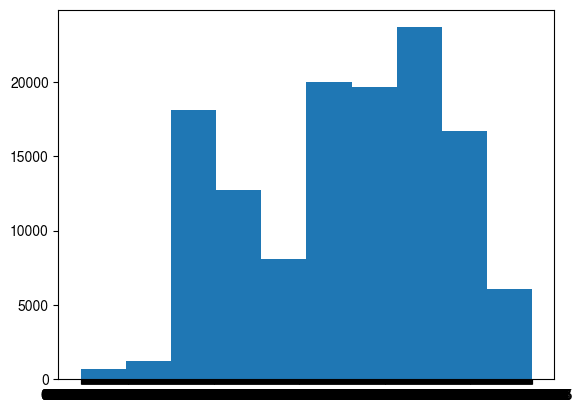

In [81]:
plt.hist(metadata['AbsPositionZ'])

In [78]:
metadata['PositionZ'].unique()

array(['4.697E-06', '1E-06', '3E-06', '5E-06'], dtype=object)

In [85]:
images = images_dict[ID]

In [86]:
v = napari.Viewer(title='testing channel enumeration')

v.add_image(images)

<Image layer 'images' at 0x7f37917a46a0>

In [87]:
images.shape

(1, 4, 3, 6911, 6911)